In [1]:
import matplotlib.pyplot as plt
import numpy as np

from agents import EpsilonGreedyAgent, bandit_agent_run
from bandit import Bandit
from estimators import SampleAverageEstimator, ConstantStepSizeEstimator
from simulation import run_simulation

%load_ext autoreload
%autoreload 2

## Initialize a specific 10-armed bandit

In [2]:
bandit = Bandit(10)

In [3]:
bandit._q_true

array([ 0.30471708, -1.03998411,  0.7504512 ,  0.94056472, -1.95103519,
       -1.30217951,  0.1278404 , -0.31624259, -0.01680116, -0.85304393])

In [4]:
[bandit.sample(a).item() for a in range(0,10)]

[1.1841150546172599,
 -0.2621921708115472,
 0.8164818933676733,
 2.0678059233592467,
 -1.4835258464017909,
 -2.1614719697455564,
 0.49659118724978424,
 -1.275125193172581,
 0.8616491438029837,
 -0.9029698385598329]

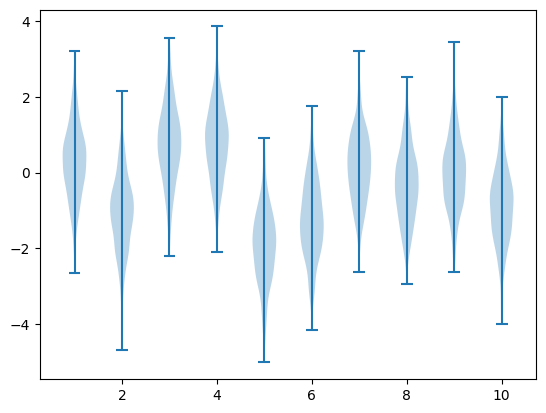

In [5]:
rewards = [bandit.sample(a, 500) for a in range(0,10)]

plt.violinplot(rewards);

## $\epsilon$-greedy action-value method

CPU times: user 4min 38s, sys: 85 ms, total: 4min 38s
Wall time: 4min 38s


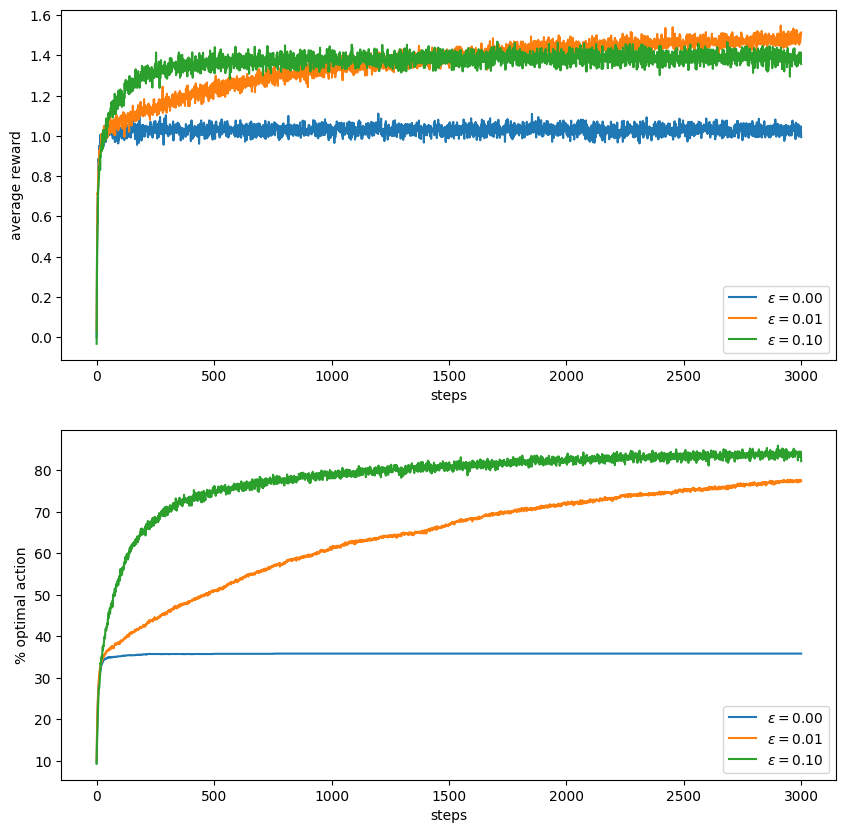

In [6]:
%%time

# Bandit parameters
k = 10                         # number of arms in the bandit

# Agent parameters
epsilons = [0.0, 0.01, 0.1]

# Simulation parameters
T = 3000                       # number of timesteps played
R = 2000                       # number of runs to play in the simulation

average_rewards = np.empty((len(epsilons), T))
percent_optimal_actions = np.empty((len(epsilons), T))

for i, epsilon in enumerate(epsilons):
    average_rewards[i], percent_optimal_actions[i] = run_simulation(R, epsilon, T, k, estimator = SampleAverageEstimator)

plt.figure(figsize=(10, 10))

plt.subplot(2, 1, 1)
for i, epsilon in enumerate(epsilons):
    plt.plot(average_rewards[i], label='$\\epsilon = %.02f$' % (epsilon))
plt.xlabel('steps')
plt.ylabel('average reward')
plt.legend()

plt.subplot(2, 1, 2)
for i, epsilon in enumerate(epsilons):
    plt.plot(percent_optimal_actions[i], label='$\\epsilon = %.02f$' % (epsilon))
plt.xlabel('steps')
plt.ylabel('% optimal action')
plt.legend()

plt.savefig('../images/figure_2_2.png')

# Simulate non-stationary Bandit algo

### Set up Bandit with drifting q_true values

In [50]:
# Bandit parameters
k = 10                         # number of arms in the bandit
q_true_mean = 0.0
q_true_var = 0.0
drift_var = 0.01

# Agent and test parameters
T = 10000                       # number of timesteps played
epsilon = 0.1
R = 2000                       # number of runs to play in the simulation

Initial optimal reward:	 0.0
Final optimal reward:	 1.34504


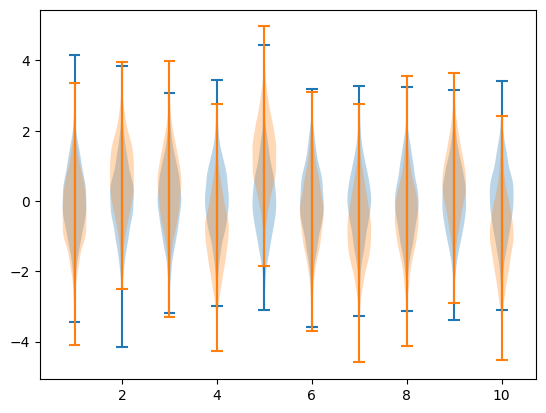

In [59]:
# Visualize an example
bandit = Bandit(k, q_true_mean, q_true_var, drift_var=drift_var)
q_true_values = np.zeros((k, T))

rewards_start = [bandit.sample(a, R) for a in range(0,k)]
print(f"Initial optimal reward:\t {round(bandit._q_true.max().item(), 5)}")

# Take a number of time steps, at each of which the q_true valus take independent random walks
for i in range(T):
    q_true_values[:,i] = bandit._q_true
    bandit.reward(0)
rewards_end = [bandit.sample(a, R) for a in range(0,k)]
print(f"Final optimal reward:\t {round(bandit._q_true.max().item(), 5)}")

plt.violinplot(rewards_start);
plt.violinplot(rewards_end);

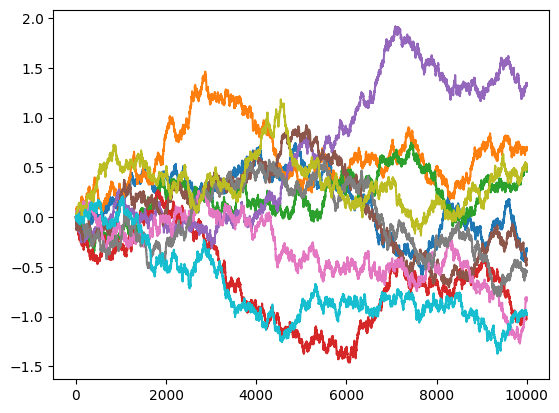

In [63]:
plt.plot(q_true_values.T);

### Compare sample-average with constant step-size action-value methods

Average reward for sample average:  0.7183599296254408
Average reward for constant step size:  -0.002361004499669125
CPU times: user 1min 5s, sys: 9.86 ms, total: 1min 5s
Wall time: 1min 5s


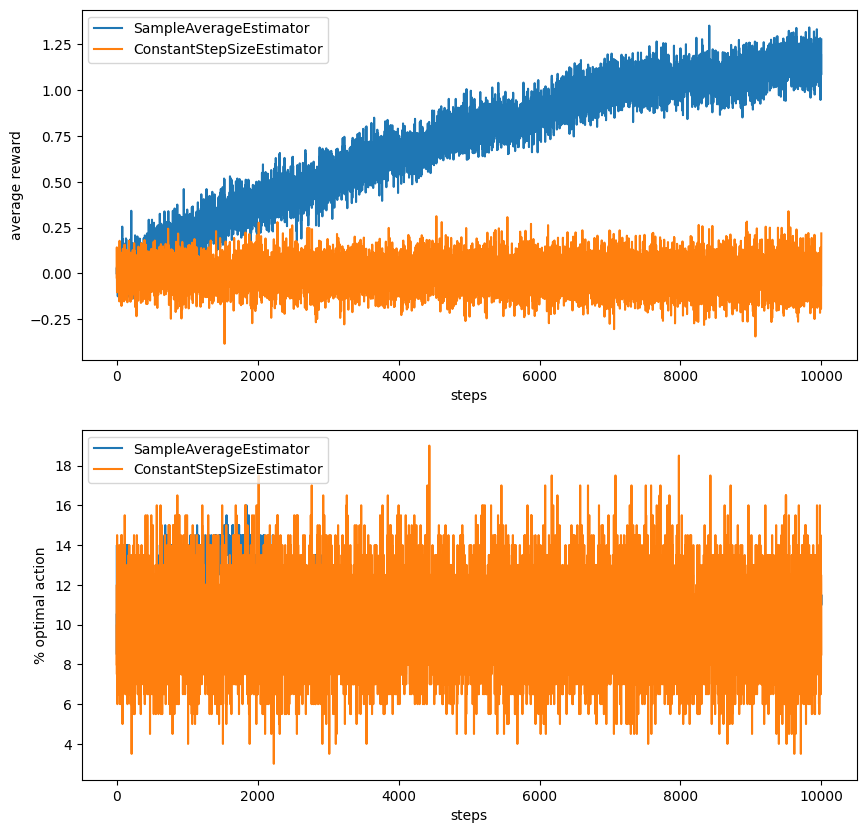

In [101]:
%%time

# Bandit parameters
k = 10                         # number of arms in the bandit
q_true_mean = 0.0
q_true_var = 0.0
drift_var = 0.01

# Agent parameters
epsilon = 0.01
estimators = [SampleAverageEstimator, ConstantStepSizeEstimator]

# Simulation parameters
T = 10000                       # number of timesteps played
R = 200                         # number of runs to play in the simulation

average_rewards = np.empty((len(estimators), T))
percent_optimal_actions = np.empty((len(estimators), T))

for i, estimator in enumerate(estimators):
    average_rewards[i], percent_optimal_actions[i] = run_simulation(R, epsilon, T, k, estimator, q_true_mean = q_true_mean, q_true_var = q_true_var, drift_var = drift_var)


print("Average reward for sample average: ", np.mean(average_rewards[0]))
print("Average reward for constant step size: ", np.mean(average_rewards[1]))


plt.figure(figsize=(10, 10))

plt.subplot(2, 1, 1)
for i, estimator in enumerate(estimators):
    plt.plot(average_rewards[i], label=estimator.__name__)
plt.xlabel('steps')
plt.ylabel('average reward')
plt.legend()

plt.subplot(2, 1, 2)
for i, estimator in enumerate(estimators):
    plt.plot(percent_optimal_actions[i], label=estimator.__name__)
plt.xlabel('steps')
plt.ylabel('% optimal action')
plt.legend()

# plt.savefig('../images/figure_2_2_ns.png')

# Debugging